#### Imports / setup

In [1]:
import pandas as pd
import numpy as np
import yaml
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, 
    RocCurveDisplay, confusion_matrix
)
from sklearn.model_selection import train_test_split
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

os.chdir("..")
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

sns.set_theme(style="whitegrid")
SEED = config["model"]["random_seed"]
print("Ready.")

Ready.


#### Load features

In [2]:
df = pd.read_parquet(config["data"]["features_dir"] + "features.parquet")

X = df.drop(columns=["default"])
y = df["default"]

print(f"Features: {X.shape[1]}  |  Rows: {len(X):,}")
print(f"Default rate: {y.mean():.1%}")

Features: 45  |  Rows: 1,345,310
Default rate: 20.0%


#### Train/val/test splits

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=config["model"]["test_size"], 
    random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config["model"]["val_size"],
    random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 968,623  |  Val: 107,625  |  Test: 269,062


#### Scale features

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done.")

Scaling done.


## Models:
 #### Standard Log Regression

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

lr_val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_scaled)[:, 1])
print(f"Logistic Regression — Val AUC: {lr_val_auc:.4f}")

Logistic Regression — Val AUC: 0.7114


#### XGBoost

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=SEED,
    eval_metric="auc",
    early_stopping_rounds=20,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
print(f"XGBoost — Val AUC: {xgb_val_auc:.4f}")

XGBoost — Val AUC: 0.7223


### NN

In [7]:
class CreditNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

# Prepare tensors
X_tr = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr = torch.tensor(y_train.values, dtype=torch.float32)
X_v  = torch.tensor(X_val_scaled, dtype=torch.float32)
y_v  = torch.tensor(y_val.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=512, shuffle=True)

model = CreditNN(X_train_scaled.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Training loop
for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    nn_probs = model(X_v).numpy()

nn_val_auc = roc_auc_score(y_val, nn_probs)
print(f"Neural Network — Val AUC: {nn_val_auc:.4f}")

Neural Network — Val AUC: 0.7149


#### Comparison

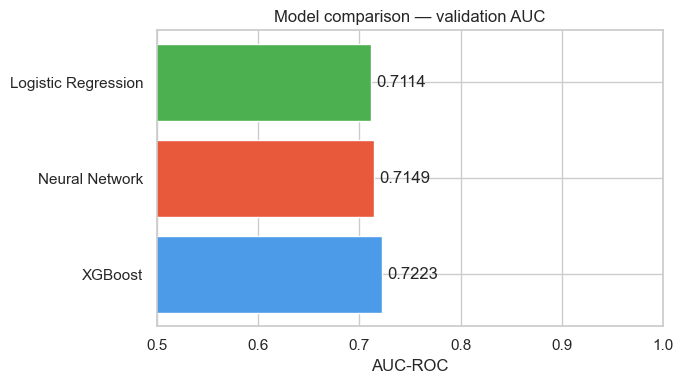

              Model  Val AUC
            XGBoost 0.722319
     Neural Network 0.714923
Logistic Regression 0.711377


In [8]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "Neural Network"],
    "Val AUC": [lr_val_auc, xgb_val_auc, nn_val_auc]
}).sort_values("Val AUC", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C9BE8", "#E8593C", "#4CAF50"]
bars = ax.barh(results["Model"], results["Val AUC"], color=colors)
ax.set_xlim(0.5, 1.0)
ax.set_title("Model comparison — validation AUC")
ax.set_xlabel("AUC-ROC")
for bar, val in zip(bars, results["Val AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center")
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

### Save Models

In [9]:
import joblib
import os

os.makedirs("src/models", exist_ok=True)

# Save all three models plus held-out test artifacts for notebook 4.
joblib.dump(lr, "src/models/logistic_regression.joblib")
joblib.dump(xgb_model, "src/models/xgboost_model.joblib")
joblib.dump(scaler, "src/models/scaler.joblib")
torch.save(model.state_dict(), "src/models/neural_net.pt")

X_test.to_parquet("src/models/X_test.parquet")
y_test.to_frame(name="default").to_parquet("src/models/y_test.parquet")

print("All models saved.")
print(f"Held-out test set saved: {len(X_test):,} rows")

All models saved.
Held-out test set saved: 269,062 rows
